In [1]:
import MDAnalysis as md
import matplotlib.pyplot as plt
import numpy as np
import cyltransf as ct

file_dir = "data100ns-2008"
output_dir = "output"

u_mean = md.Universe(file_dir + "/md_1.tpr", output_dir + "/md_1_mean.xtc")
chains = u_mean.select_atoms("protein").fragments

Get Mol Res

In [20]:
mol = 26
molecule = chains[3*mol:3*mol + 3]
molecule_coords = (molecule[0] + molecule[1]+ molecule[2]).positions

len_mol = (molecule_coords[:,2].max() - molecule_coords[:,2].min()) / 10

molecule_mean_filt = ct.remove_ends(0.5, molecule_coords) / 10

# Cylindrical Coordinates
rad_mol, phi_mol, z_mol = ct.cyl_proj(molecule_mean_filt)

New calc: "Separation from the fit"
$$
s = | r\varphi - r\varphi_{\text{fit}} |
$$
That is, try to quantizise how stretch the atoms get from the molecule fit? Also a way to quantify how stretch the proyection is, ie, how well will it be.

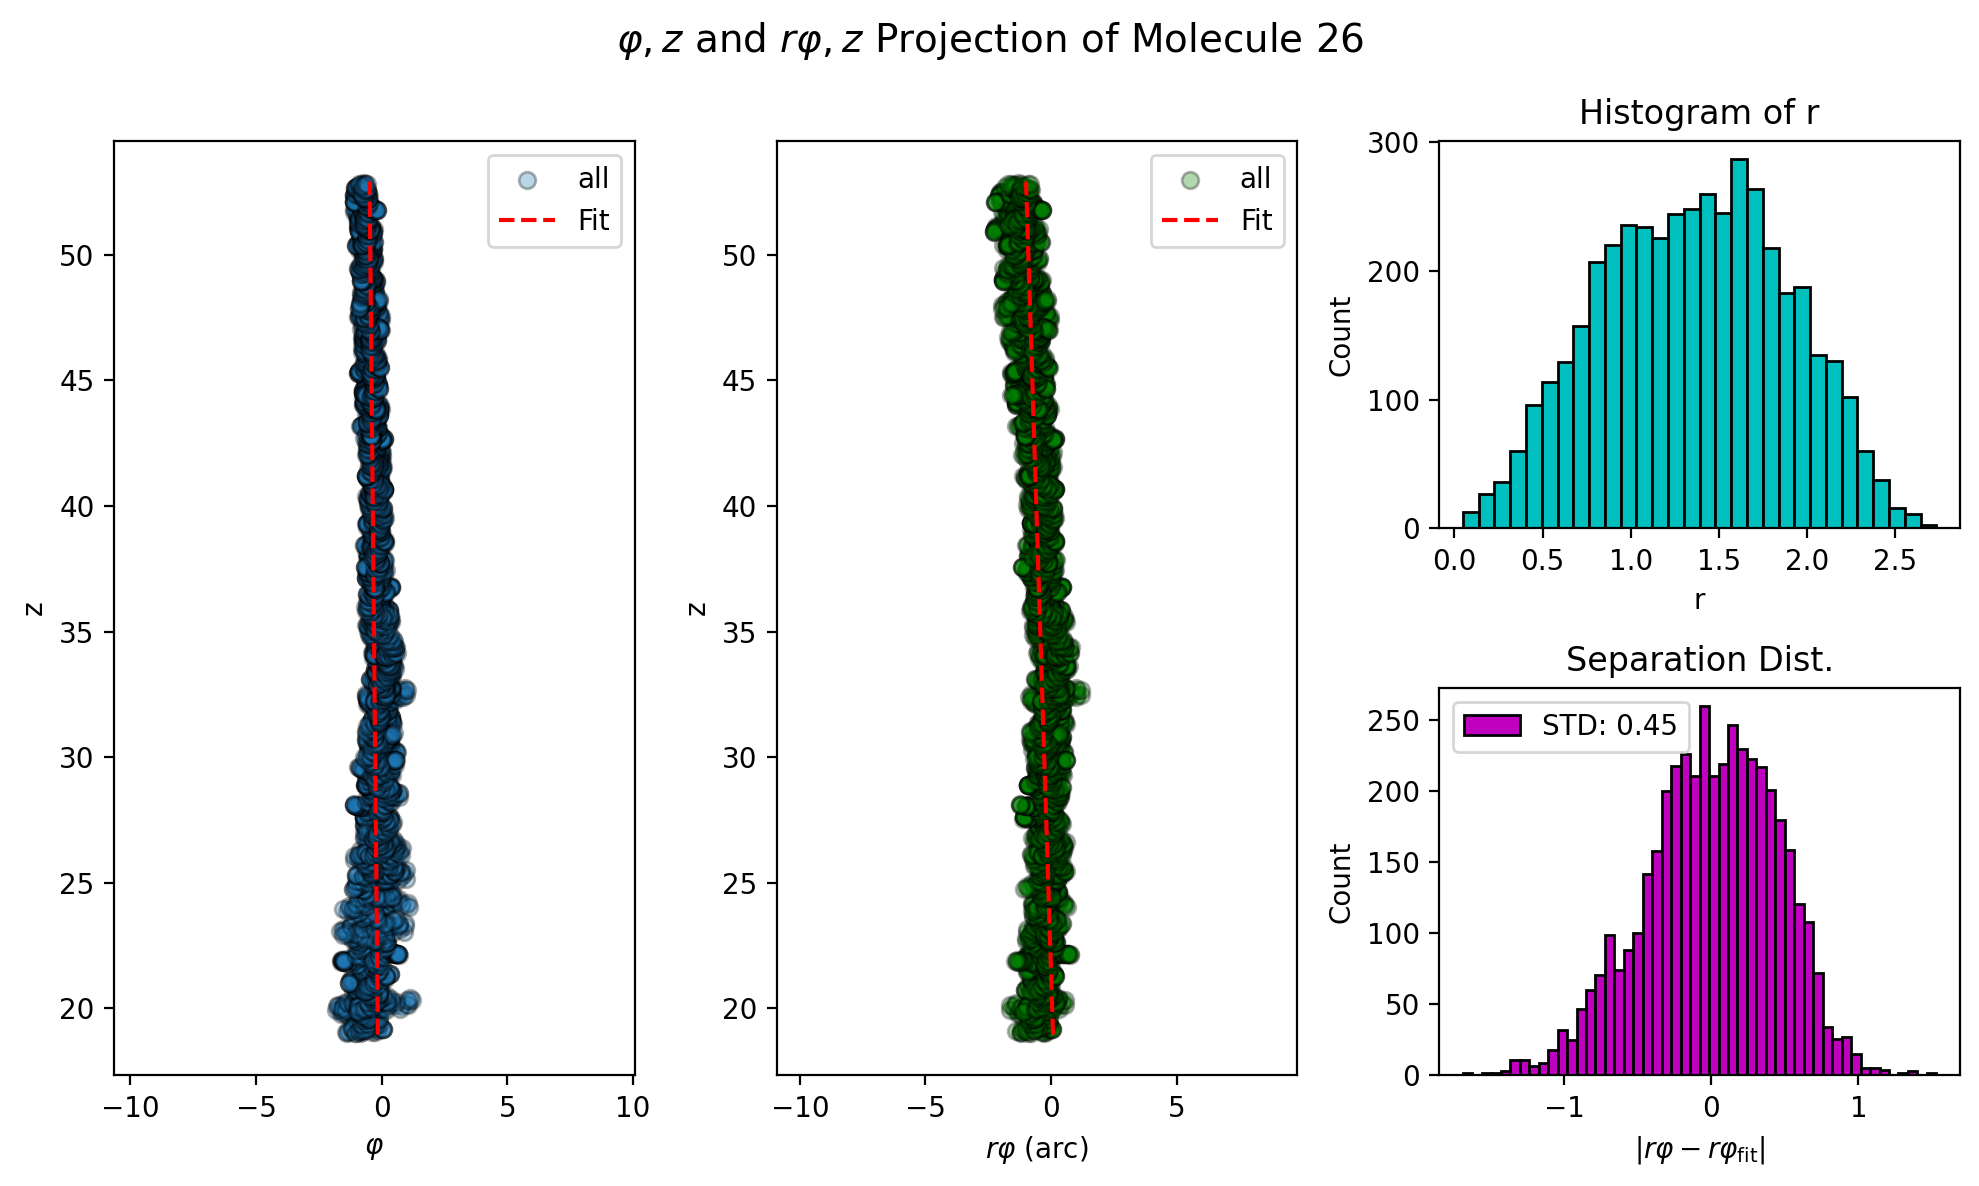

In [21]:
from matplotlib.gridspec import GridSpec

atoms_label = 'all'
arc_mol = rad_mol * phi_mol

fig = plt.figure(figsize=(10, 6), dpi=200)
gs = GridSpec(2, 3, figure=fig)  # 2 rows, 3 columns

# --- Phi vs Z --- 
ax0 = fig.add_subplot(gs[:, 0])
ax0.scatter(phi_mol, z_mol, alpha=0.3, edgecolor='k', label=atoms_label)
b, m = np.polynomial.polynomial.polyfit(z_mol, phi_mol, 1)
fit = np.polynomial.polynomial.Polynomial((b, m))
ax0.plot(fit(z_mol), z_mol, linestyle='dashed', color='r', label='Fit')
ax0.axis('equal')
ax0.set_xlabel(r'$\varphi$')
ax0.set_ylabel(r'z')
ax0.legend()

# --- Arc vs Z ---
ax1 = fig.add_subplot(gs[:, 1])
ax1.scatter(arc_mol, z_mol, color='g', alpha=0.3, edgecolor='k', label=atoms_label)
m, b, r2_mol = ct.linfitandr2(z_mol, arc_mol)
fit = np.polynomial.polynomial.Polynomial((b, m))
ax1.plot(fit(z_mol), z_mol, linestyle='dashed', color='r', label='Fit')
ax1.axis('equal')
ax1.set_xlabel(r'$r\varphi$ (arc)')
ax1.set_ylabel(r'z')
ax1.legend()

# --- Histogram r ---
ax2 = fig.add_subplot(gs[0, 2])
ax2.hist(rad_mol, bins=30, color='c', edgecolor='k')
ax2.set_xlabel('r')
ax2.set_ylabel('Count')
ax2.set_title('Histogram of r')

# --- Separation / Strechness ---
sep = arc_mol - fit(z_mol)
std_sep = np.std(sep)

ax3 = fig.add_subplot(gs[1, 2])
ax3.hist(sep, bins=50, color='m', edgecolor='k', label=f"STD: {std_sep:.2f}")
ax3.set_xlabel(r'$|r\varphi - r\varphi_\text{fit}|$')
ax3.set_ylabel('Count')
ax3.set_title(r'Separation Dist.')
ax3.legend()

plt.suptitle(rf'$\varphi, z$ and $r\varphi, z$ Projection of Molecule {mol}', fontsize=14)
plt.tight_layout()
plt.show()
